In [90]:
#importing the warnings.
import warnings
warnings.filterwarnings('ignore')

In [91]:
#importing the useful libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Part A — Data preparation

### 1. Loading the fear_greed_index dataset

In [92]:
#Using set_option to display all the columns for better understanding of data
pd.set_option('display.max_columns', None)

In [93]:
#reading the data set "fear_greed_index" in fg_data
fg_data = pd.read_csv('fear_greed_index.csv')
fg_data.head(6)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
5,1517895000,8,Extreme Fear,2018-02-06


### Loading the historical_data dataset

In [94]:
#reading the data set "historical_data" in h_data
h_data = pd.read_csv('historical_data.csv')
h_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Finding the number of rows and columns in both the datasets

In [95]:
#Checking the number of rows and columns in both the datasets
fg_data.shape

(2644, 4)

In [96]:
h_data.shape

(211224, 16)

### Finding the missing values in both the datasets

In [97]:
#Checking the missing values in fg_data
fg_data.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [98]:
#Checking the missing values in h_data
h_data.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


### Finding the duplicate values in both the datasets

In [99]:
fg_data.duplicated().sum()

np.int64(0)

In [100]:
h_data.duplicated().sum()

np.int64(0)

### 2. Convert timestamps and align the datasets by date (daily level is fine)

In [101]:
#Converting timestamp column to datetime objects in fg_data
fg_data['timestamp'] = pd.to_datetime(fg_data['timestamp'], unit='s').dt.date
fg_data.head()

,timestamp,value,classification,date
0,2018-02-01,30,Fear,2018-02-01
1,2018-02-02,15,Extreme Fear,2018-02-02
2,2018-02-03,40,Fear,2018-02-03
3,2018-02-04,24,Extreme Fear,2018-02-04
4,2018-02-05,11,Extreme Fear,2018-02-05


In [102]:
#Converting date column to datetime objects in fg_data
fg_data['date'] = pd.to_datetime(fg_data['date']).dt.date
fg_data.head()

,timestamp,value,classification,date
0,2018-02-01,30,Fear,2018-02-01
1,2018-02-02,15,Extreme Fear,2018-02-02
2,2018-02-03,40,Fear,2018-02-03
3,2018-02-04,24,Extreme Fear,2018-02-04
4,2018-02-05,11,Extreme Fear,2018-02-05


In [103]:
#Converting timestamps to datetime objects in h_data
h_data['Timestamp'] = pd.to_datetime(h_data['Timestamp'], unit='ms').dt.date
h_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27


In [104]:
#Converting timestamps IST to datetime objects in h_data
h_data['Timestamp IST'] = pd.to_datetime(h_data['Timestamp IST'], dayfirst=True, format='mixed').dt.date
h_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27


### Checking the date range of date columns in both the datasets

In [105]:
#Checking the range of date column in fg_data
fg_data['date'].agg(['min', 'max'])

,date
min,2018-02-01
max,2025-05-02


In [106]:
#Checking the range of timestamp column in fg_data
fg_data['timestamp'].agg(['min', 'max'])

,timestamp
min,2018-02-01
max,2025-05-02


In [107]:
#Checking the range of Timestamp column in h_data
h_data['Timestamp'].agg(['min', 'max'])

,Timestamp
min,2023-03-28
max,2025-06-15


In [108]:
#Checking the range of Timestamp IST column in h_data
h_data['Timestamp IST'].agg(['min', 'max'])

,Timestamp IST
min,2023-05-01
max,2025-05-01


### Checking the unique values in date columns both the datasets

In [109]:
#Checking the unique values in timestamp column in fg_data
fg_data['timestamp'].nunique()

2644

In [110]:
#Checking the unique values in date column in fg_data
fg_data['date'].nunique()

2644

In [111]:
#Checking the unique values in Timestamp column in h_data
h_data['Timestamp'].nunique()

7

In [112]:
#Checking the unique values in Timestamp IST column in h_data
h_data['Timestamp IST'].nunique()

480

### Observation:
1. As we can see, the 'timestamp' column and the 'date' column in fg_data has same values, so we can drop one of these columns.
2. The 'Timestamp' column in h_data has only 7 unique values. There might be some errors or the data is corrupted in this column, so we can drop this column.
3. Also, there is a mismatch in the 'Timestamp' column and the 'Timestamp IST' column in h_data.
4. As 'Timestamp IST' column include correct data, so we can merge both the datasets using 'date' column from fg_data and 'Timestamp IST' column from h_data.
5. Other redundant date columns such as 'timestamp' from fg_data and 'Timestamp' from h_data can be dropped.

### Merging both the datasets

In [113]:
#Merging both the data sets on Timestamp column (inner join)
aligned_data = pd.merge(fg_data, h_data, left_on='date', right_on='Timestamp IST', how='inner')
aligned_data.head()

,timestamp,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,2023-05-01,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,2023-05-01,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
1,2023-05-01,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,2023-05-01,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
2,2023-05-01,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,2023-05-01,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
3,2023-12-05,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,BUY,2023-12-05,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.275027,6.320000e+14,2023-11-14
4,2023-12-05,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,BUY,2023-12-05,0.4933,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.483987,2.340000e+14,2023-11-14


### Dropping the redundant date columns in both the datasets

In [114]:
aligned_data = aligned_data.drop(['timestamp', 'Timestamp', 'Timestamp IST'], axis=1)


In [115]:
#Checking the number of rows and columns of new merged dataset
aligned_data.shape

(211218, 17)

In [116]:
#Checking the missing values of aligned_data
aligned_data.isnull().sum()

,0
value,0
classification,0
date,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Start Position,0


In [117]:
#Checking the duplicate values of aligned_data
aligned_data.duplicated().sum()

np.int64(0)

In [118]:
#Sorting the dataset by date
aligned_data = aligned_data.sort_values('date')
aligned_data.head()

,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID
0,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00
1,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00
2,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00
11,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14
10,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,0.0000,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,0.157001,1.070000e+15


### 3. Creating the key metrics

In [119]:
daily_pnl = aligned_data.groupby(['date', 'Trade ID'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,Trade ID,Closed PnL
0,2023-05-01,0.000000e+00,0.0
1,2023-12-05,2.340000e+14,0.0
2,2023-12-05,2.580000e+14,0.0
3,2023-12-05,2.830000e+14,0.0
4,2023-12-05,2.920000e+14,0.0


In [120]:
#creating a new is_win Column (1 for profit, 0 for no profit)
aligned_data['is_win'] = (aligned_data['Closed PnL'] > 0).astype(int)
aligned_data.head()

,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,is_win
0,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0
1,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0
2,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0
11,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14,0
10,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,0.0000,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,0.157001,1.070000e+15,0


In [121]:
#Calculating win rate
win_rate = aligned_data['is_win'].mean()*100
print({win_rate})

{np.float64(41.124809438589516)}


In [122]:
#Calculating average trade size
avg_trade_size = round((aligned_data['Size USD'].sum())/(aligned_data['Account'].count()),2)
print({avg_trade_size})

{np.float64(5639.19)}


In [123]:
#Creating a new column 'leverage'
aligned_data['leverage'] = aligned_data['Size Tokens'] - aligned_data['Start Position']
aligned_data.head()

,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,is_win,leverage
0,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,0.09670
1,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.01430
2,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.10690
11,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14,0,0.59711
10,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,0.0000,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,0.157001,1.070000e+15,0,0.01500


In [124]:
#Creating a new column 'leverage_standard'
aligned_data['leverage_standard'] = aligned_data['leverage'].abs().clip(upper=100)
aligned_data.head()

,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,is_win,leverage,leverage_standard
0,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,0.09670,0.09670
1,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.01430,0.01430
2,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.10690,0.10690
11,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14,0,0.59711,0.59711
10,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,0.0000,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,0.157001,1.070000e+15,0,0.01500,0.01500


In [125]:
#Leverage Distribution
#Creating bins and labels for leverage distribution
bins = [0, 1.1, 5.1, 10.1, 25.1, 50.1, 100]

#Defining the labels for these buckets
labels = ['1x', '5x', '10x', '25x', '50x', '100x']

#Applying the bins to the column 'leverage_standard'
aligned_data['leverage_category'] = pd.cut(aligned_data['leverage_standard'], bins=bins, labels=labels)

#Checking the new column
print(aligned_data['leverage_standard'].value_counts().sort_index())

leverage_standard
0.000000e+00      1979
3.000000e-09         1
2.500000e-08         1
2.800000e-08         1
4.400000e-08         1
                 ...  
9.993000e+01         1
9.994747e+01         1
9.996000e+01         2
9.996600e+01         1
1.000000e+02    164393
Name: count, Length: 40505, dtype: int64


In [147]:
aligned_data.head()

,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,is_win,leverage,leverage_standard,leverage_category,leverage_num,leverage_type
0,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,0.09670,0.09670,1x,1.0,Low Leverage
1,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.01430,0.01430,1x,1.0,Low Leverage
2,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.10690,0.10690,1x,1.0,Low Leverage
11,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14,0,0.59711,0.59711,1x,1.0,Low Leverage
10,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,0.0000,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,0.157001,1.070000e+15,0,0.01500,0.01500,1x,1.0,Low Leverage


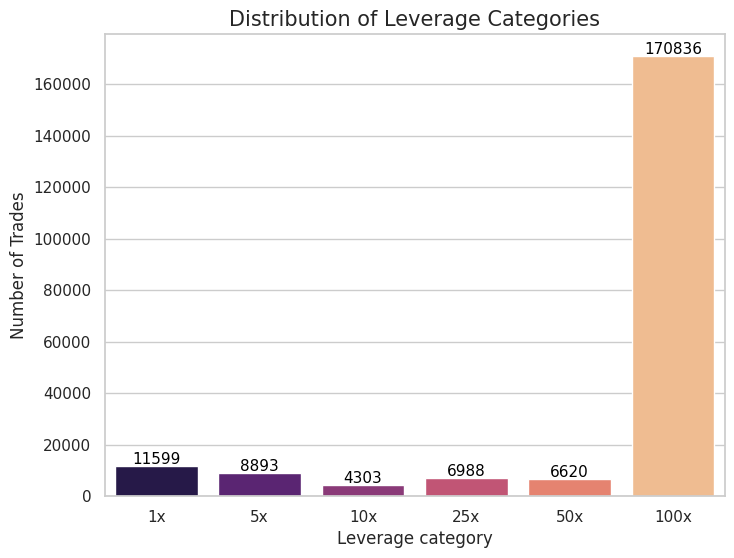

In [149]:
#Leverage distribution based on leverage category
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Use the column name 'trader_type' or whatever categorical column you have
sns.countplot(data=aligned_data, x='leverage_category', palette='magma')

plt.title('Distribution of Leverage Categories', fontsize=15)
plt.xlabel('Leverage category', fontsize=12)
plt.ylabel('Number of Trades', fontsize=12)

# Optional: Add the exact counts on top of each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.savefig('leverage_distribution.png')

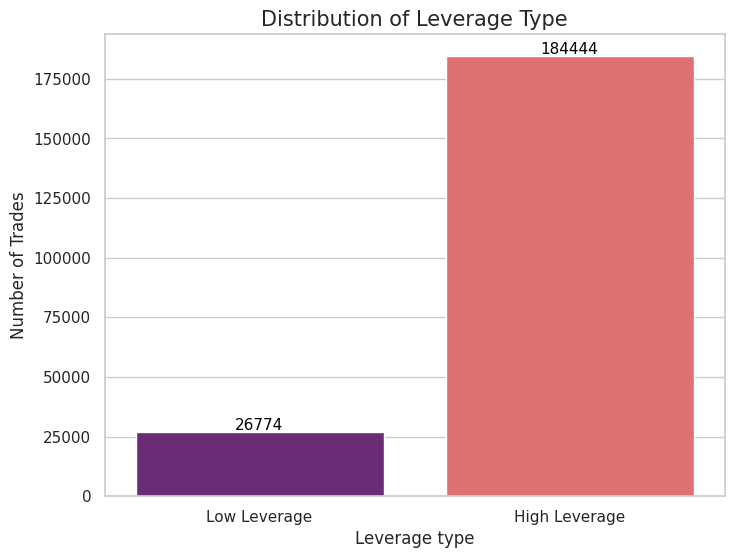

In [150]:
#Leverage distribution based on leverage type
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Use the column name 'trader_type' or whatever categorical column you have
sns.countplot(data=aligned_data, x='leverage_type', palette='magma')

plt.title('Distribution of Leverage Type', fontsize=15)
plt.xlabel('Leverage type', fontsize=12)
plt.ylabel('Number of Trades', fontsize=12)

# Optional: Add the exact counts on top of each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.savefig('leverage_distribution.png')

In [127]:
#Number of trades per day
trades_per_day = aligned_data.groupby(['date'])['Trade ID'].count().reset_index()
trades_per_day.head()

,date,Trade ID
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [128]:
#long/short ratio
counts = aligned_data['Side'].value_counts()
ls_ratio = counts['BUY']/counts['SELL']

print(f"Total Buy: {counts['BUY']}")
print(f"Total Sell: {counts['SELL']}")
print(f"long/short ratio: {ls_ratio}")

Total Buy: 102690
Total Sell: 108528
long/short ratio: 0.9462074303405573


In [129]:
#Creating a function to calculate metrics for a group
def get_stats(group):
    wins = group[group['Closed PnL'] > 0]
    win_rate = (len(wins) / len(group)) * 100
    avg_pnl = group['Closed PnL'].mean()
    total_pnl = group['Closed PnL'].sum()
    max_drawdown_proxy = group['Closed PnL'].min() #Largest single loss
    longs = len(group[group['Side'].str.contains('BUY', case=False, na=False)])
    shorts = len(group[group['Side'].str.contains('SELL', case=False, na=False)])
    position_size = group['Size USD'].sum()

    return pd.Series({
        'Trade Count': len(group),
        'Total PnL': total_pnl,
        'Avg PnL': avg_pnl,
        'Win Rate %': win_rate,
        'Max Single Loss': max_drawdown_proxy,
        'long_short_ratio': longs/shorts,
        'Position Size': position_size
    })

#Group by sentiment classification and apply
performance_comparison = aligned_data.groupby('classification').apply(get_stats)

#Displaying result
print(performance_comparison)

                Trade Count     Total PnL    Avg PnL  Win Rate %  \
classification                                                     
Extreme Fear        21400.0  7.391102e+05  34.537862   37.060748   
Extreme Greed       39992.0  2.715171e+06  67.892861   46.494299   
Fear                61837.0  3.357155e+06  54.290400   42.076750   
Greed               50303.0  2.150129e+06  42.743559   38.482794   
Neutral             37686.0  1.292921e+06  34.307718   39.699093   

                Max Single Loss  long_short_ratio  Position Size  
classification                                                    
Extreme Fear       -31036.69194          1.044912   1.144843e+08  
Extreme Greed      -10259.46800          0.813532   1.244652e+08  
Fear               -35681.74723          0.958913   4.833248e+08  
Greed             -117990.10410          0.955261   2.885825e+08  
Neutral            -24500.00000          1.013464   1.802421e+08  


# Part B — Analysis

### Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

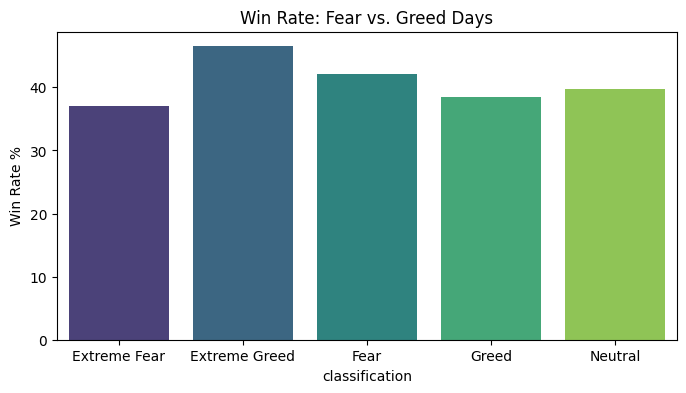

In [130]:
plt.figure(figsize=(8, 4))
sns.barplot(x=performance_comparison.index, y=performance_comparison['Win Rate %'], palette='viridis')
plt.title('Win Rate: Fear vs. Greed Days')
plt.ylabel('Win Rate %')
plt.show()

### Observations:
1. Trading performance peaked during periods of "Extreme Greed", yielding the highest win rate. This suggests the trader successfully capitalized on strong upward momentum.
2. Conversely, win rates reached their lowest point during "Extreme Fear" days.
3. Despite the fluctuations in market emotion, the win rate remains stable across all sentiment categories and largely independent of external market hype.

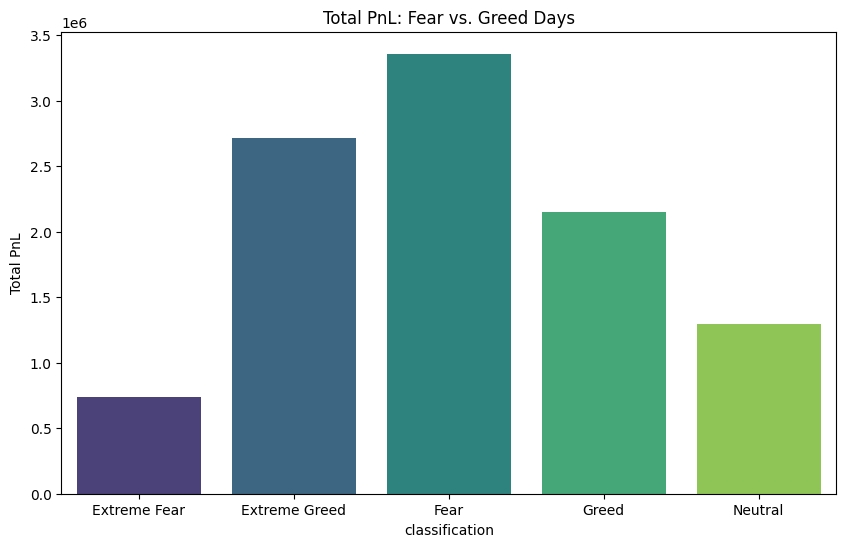

In [131]:
plt.figure(figsize=(10, 6))
sns.barplot(x=performance_comparison.index, y=performance_comparison['Total PnL'], palette='viridis')
plt.title('Total PnL: Fear vs. Greed Days')
plt.ylabel('Total PnL')
plt.show()

### Observations:
1. The highest net profits were recorded during "Fear" sentiment. By "buying the dip" at lower prices, traders are entering the market at a discount, which leads to much better profit margins when the price bounces back.
2. Profitability in "Greed" and "Extreme Greed" significantly outperformed "Neutral" market conditions. This indicates that traders are successfully riding strong trend momentum.
3. Despite markets being at their lowest, profit levels or activity dropped during "Extreme Fear." During periods of extreme volatility and panic selling, traders appear to prioritize safety over profit.

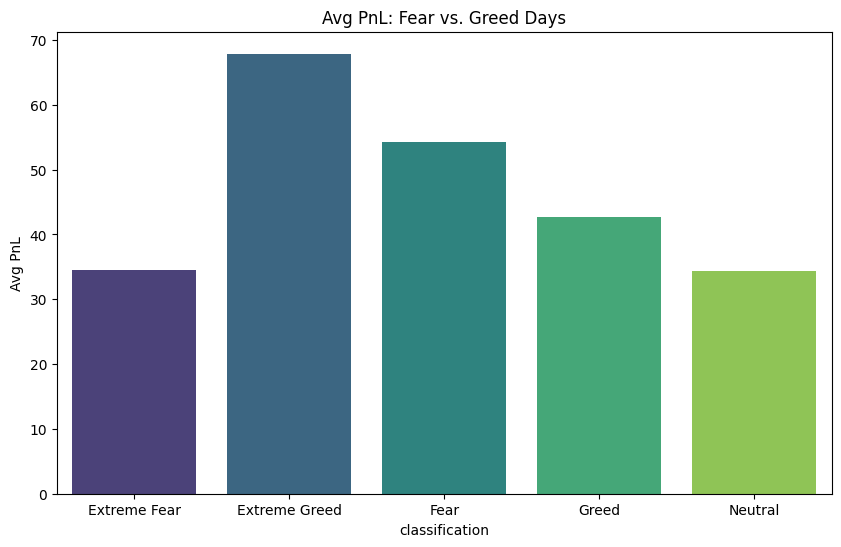

In [132]:
plt.figure(figsize=(10, 6))
sns.barplot(x=performance_comparison.index, y=performance_comparison['Avg PnL'], palette='viridis')
plt.title('Avg PnL: Fear vs. Greed Days')
plt.ylabel('Avg PnL')
plt.show()

### Observations:
1. Average profits reach their peak during "Extreme Greed" conditions. This suggests a lower volume of trades, where successful "trend riding" allows for the highest possible profit margins on a per-trade basis.
2. Both "Fear" and "Greed" sentiments maintain high levels of profitability. This indicates a balanced ability to extract value from the market during both "buy-the-dip" opportunities and standard upward momentum.

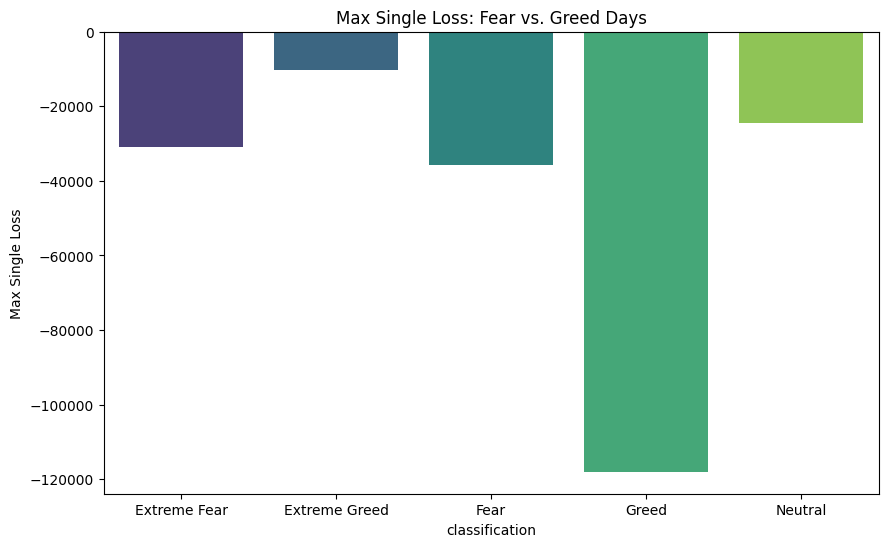

In [133]:
plt.figure(figsize=(10, 6))
sns.barplot(x=performance_comparison.index, y=performance_comparison['Max Single Loss'], palette='viridis')
plt.title('Max Single Loss: Fear vs. Greed Days')
plt.ylabel('Max Single Loss')
plt.show()

### Observations:
1. Average profits are highest during "Extreme Greed" because of successful trend riding. During this time, the largest single loss is at its lowest, showing that trades are safer and more profitable.
2. The maximum amount lost on a single trade is almost the same in every sentiment. The only exception is the "Greed" period, where losses behave differently.
3. Because "Greed" periods see the largest single losses, the total and average profits are held back. These big individual losses prevent this sentiment from being the most profitable overall.

### 2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

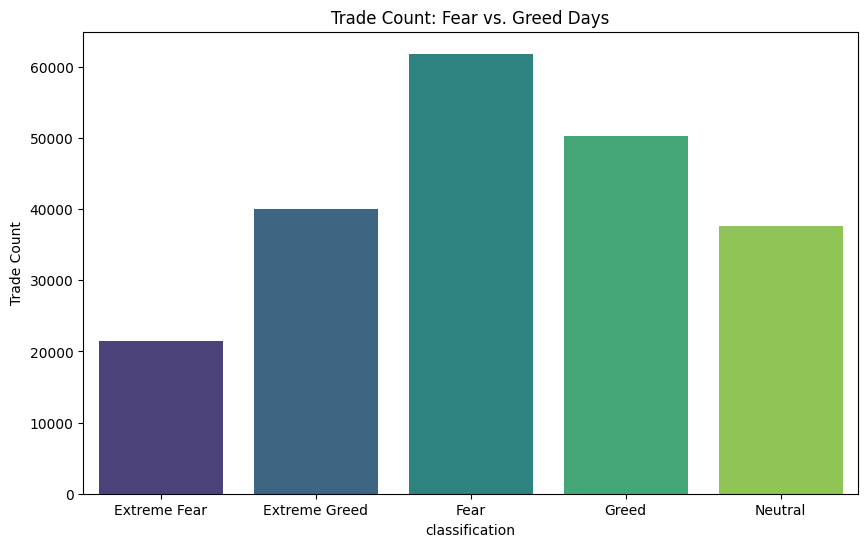

In [134]:
plt.figure(figsize=(10, 6))
sns.barplot(x=performance_comparison.index, y=performance_comparison['Trade Count'], palette='viridis')
plt.title('Trade Count: Fear vs. Greed Days')
plt.ylabel('Trade Count')
plt.show()

### Observations:
1. The largest number of trades happened during "Fear" periods. Because so many trades were made, the total profit for this sentiment is the highest overall.
2. Trading activity was highest during "Fear" and "Greed" periods. On the other hand, the fewest number of trades happened during "Extreme Fear" moments.
3. The number of trades made during "Extreme Greed" was almost exactly the same as the number of trades made during "Neutral" sentiment.

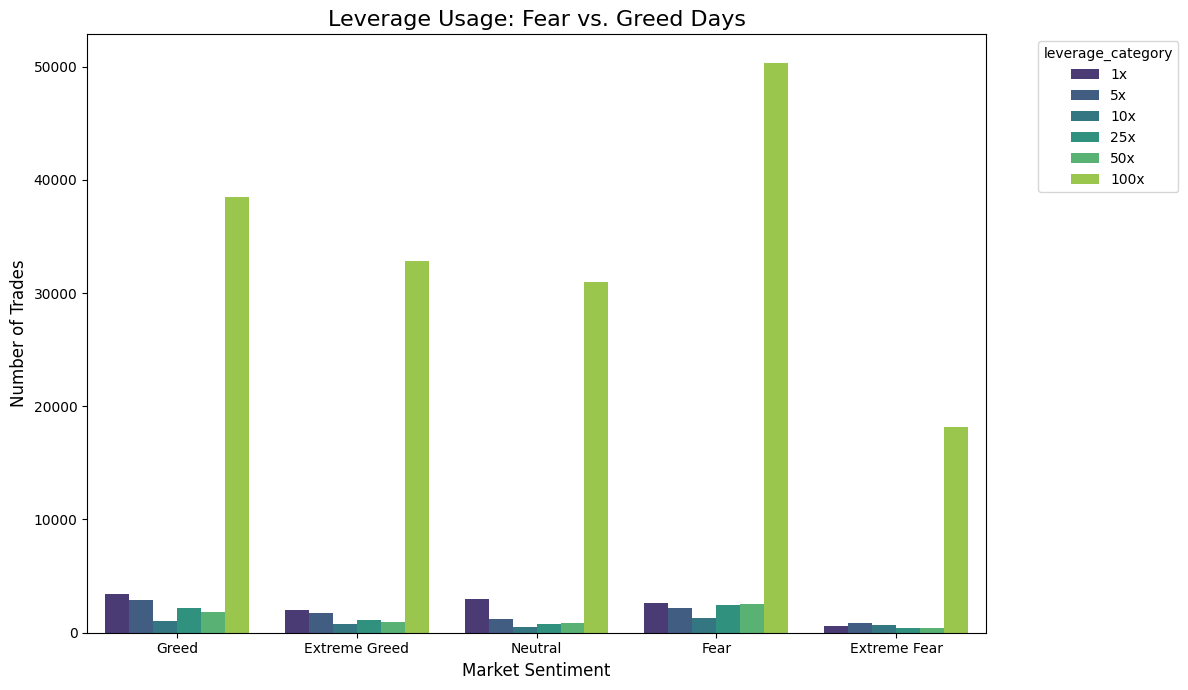

In [135]:
#sizing the chart
plt.figure(figsize=(12, 7))

#Using countplot to compare the two categories
#x: The main category (Fear vs Greed)
#hue: The sub-category (The leverage breakdown)
sns.countplot(
    data=aligned_data,
    x='classification',
    hue='leverage_category',
    palette='viridis'
)

#adding labels and titles
plt.title('Leverage Usage: Fear vs. Greed Days', fontsize=16)
plt.ylabel('Number of Trades', fontsize=12)
plt.xlabel('Market Sentiment', fontsize=12)

#Moving the legend outside so it doesn't cover the bars
plt.legend(title='leverage_category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Observations:
1. The highest number of 100x leverage trades took place during "Fear" periods. This shows that despite the market being down, traders were taking their biggest risks during these times.
2. Using 100x leverage was most common during "Fear" and "Greed" periods. In contrast, the lowest amount of 100x leverage was used during "Extreme Fear," showing that traders played it much safer during total market panics.
3. The 100x leverage used during "Extreme Greed" was almost the same as during "Neutral" sentiment.

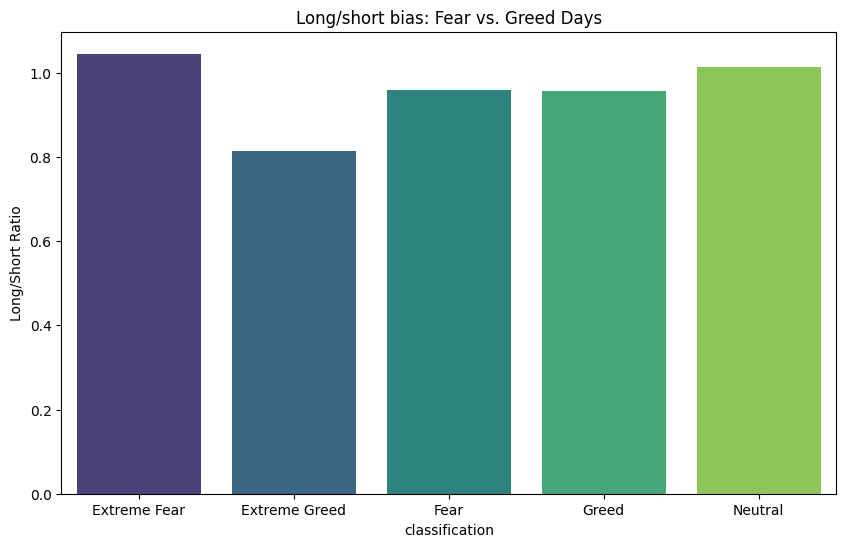

In [136]:
plt.figure(figsize=(10, 6))
sns.barplot(x=performance_comparison.index, y=performance_comparison['long_short_ratio'], palette='viridis')
plt.title('Long/short bias: Fear vs. Greed Days')
plt.ylabel('Long/Short Ratio')
plt.show()

### Observations:
The long/short ratio remains almost exactly the same across every market sentiment. This suggests that the trader maintains a very steady balance between buying and selling, regardless of whether the market is feeling greedy or fearful.

### 3.1 High leverage vs low leverage traders

In [137]:
#Extracting the numbers from leverage_category
aligned_data['leverage_num'] = aligned_data['leverage_category'].str.extract('(\d+)').astype(float)

#Making a new category column
aligned_data['leverage_type'] = aligned_data['leverage_num'].apply(
    lambda x: 'High Leverage' if x > 10 else 'Low Leverage'
)

aligned_data.head()

,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,is_win,leverage,leverage_standard,leverage_category,leverage_num,leverage_type
0,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,0.09670,0.09670,1x,1.0,Low Leverage
1,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.01430,0.01430,1x,1.0,Low Leverage
2,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,0,-0.10690,0.10690,1x,1.0,Low Leverage
11,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14,0,0.59711,0.59711,1x,1.0,Low Leverage
10,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,0.0000,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,0.157001,1.070000e+15,0,0.01500,0.01500,1x,1.0,Low Leverage


In [138]:
aligned_data['leverage_type'].value_counts()

,count
leverage_type,
High Leverage,184444
Low Leverage,26774


In [139]:
#Creating a pivot table to count 'High' and 'Low' for each Trade ID
leverage_counts = pd.crosstab(aligned_data['Trade ID'], aligned_data['leverage_type'])

segment_comparison = aligned_data.groupby('Trade ID').agg({
    'leverage_type': ['count']
})

#Combining them into one table
segment_comparison = pd.concat([leverage_counts, segment_comparison], axis=1)

segment_comparison.head()

,High Leverage,Low Leverage,"(leverage_type, count)"
Trade ID,,,
0.000000e+00,0,145,145
2.367595e+09,1,0,1
3.739256e+09,1,0,1
9.506002e+09,1,0,1
1.162660e+10,1,0,1


In [140]:
#Grouping by Trade ID to find the "Trader's Profile" for each trade
trader_comparison = aligned_data.groupby('Trade ID').agg({
    'leverage_num': 'max',           #Defining them by their highest risk taken
    'Closed PnL': 'sum',             #The final profit/loss for that trader
    'Size USD': 'mean'               #Their average buying power
}).reset_index()

#Labeling the 'Trader Type'
trader_comparison['trader_type'] = trader_comparison['leverage_num'].apply(
    lambda x: 'High Leverage' if x > 10 else 'Low Leverage'
)

#comparing the Traders
final_analysis = trader_comparison.groupby('trader_type').agg({
    'Closed PnL': ['mean', 'sum'],
    'Trade ID': 'count'
})

print(final_analysis)

                Closed PnL               Trade ID
                      mean           sum    count
trader_type                                      
High Leverage  3722.657974  1.025220e+07     2754
Low Leverage     40.837287  2.286888e+03       56


### Observations:
1. High Leverage traders generated huge amounts in total profit, as compared to Low Leverage traders. This shows that the vast majority of the portfolio's wealth is being driven by high-leverage activity.
2. The average profit for a High Leverage trader is 3722, which is nearly 100 times higher than the $40 average seen in Low Leverage traders. This indicates that high-leverage strategies are significantly more effective at extracting large gains from the market.
3. There were 2,754 High Leverage trades compared to only 56 Low Leverage trades. This suggests that the current trading strategy is heavily focused on high-risk, high-reward positions, with very little activity in the low-risk category.

### 3.2 Frequent vs Infrequent traders

In [143]:
#Analysing the activity status of the traders
activity_stats = aligned_data['Trade ID'].value_counts()

print(f"Minimum trades by one person: {activity_stats.min()}")
print(f"Average (Mean) trades: {activity_stats.mean():.2f}")
print(f"Middle Point (Median) trades: {activity_stats.median()}")
print(f"Most trades by one person: {activity_stats.max()}")

Minimum trades by one person: 1
Average (Mean) trades: 75.17
Middle Point (Median) trades: 18.0
Most trades by one person: 1946


### Observation:
Since some individual traders show extremely high activity with one trader reaching nearly 2,000 trades and the average activity level sits at 75 trades per person. For most active traders, we have set the threshold for a Frequent Trader at 75 or more trades. This allows us to clearly distinguish between casual participants and the high-volume traders driving the market.

In [144]:
#counting how many times each Trade ID appears (Activity Level)
trade_counts = aligned_data['Trade ID'].value_counts()

#Defining the threshold
trader_type_map = trade_counts.apply(lambda x: 'Frequent Trader' if x > 75 else 'Infrequent Trader')

#Group by Trade ID to get the total performance for each person
trader_summary = aligned_data.groupby('Trade ID').agg({
    'Closed PnL': 'sum',
    'Trade ID': 'count'
})
trader_summary.columns = ['Total_PnL', 'Activity_Count']

#Applying the frequency label
trader_summary['frequency_type'] = trader_summary.index.map(trader_type_map)

#Final Comparison: Frequent vs Infrequent
freq_analysis = trader_summary.groupby('frequency_type').agg({
    'Total_PnL': ['mean', 'sum'],
    'Activity_Count': ['sum', 'count']
})

#Flatten column names for clarity
freq_analysis.columns = ['Avg_Profit_Per_Trader', 'Grand_Total_Profit', 'Total_Trades_Made', 'Number_of_Traders']

print(freq_analysis)

                   Avg_Profit_Per_Trader  Grand_Total_Profit  \
frequency_type                                                 
Frequent Trader             10385.287777        9.502538e+06   
Infrequent Trader             396.806667        7.519486e+05   

                   Total_Trades_Made  Number_of_Traders  
frequency_type                                           
Frequent Trader               192461                915  
Infrequent Trader              18757               1895  


### Observations:
1. Frequent Traders are the primary drivers and generates more profits as compared to infrequent traders, despite being the smaller group in terms of people.
2. The Average Profit per trader for the frequent group is 10,385, which is nearly 25 times higher than the $396 average of infrequent traders. This proves that high activity levels correlate strongly with higher trading skill and better financial outcomes.
3. The group of 915 frequent traders is responsible for 192,461 trades, while the 1,895 infrequent traders account for only 18,757. This highlights that the frequent group which consists of highly skilled and active participants is driving 10 times the trade volume of the infrequent group, despite having less than half the number of people.

### 3.3 Consistent winners vs inconsistent traders

In [145]:
#Group by Trade ID to get the stats for each trader
trader_perf = aligned_data.groupby('Trade ID').agg({
    'Closed PnL': ['sum', 'count', lambda x: (x > 0).sum()]
})

#Renaming columns
trader_perf.columns = ['Total_PnL', 'Trade_Count', 'Wins']

#Calculating individual Win Rate
trader_perf['Win_Rate'] = (trader_perf['Wins'] / trader_perf['Trade_Count']) * 100

#Labeling the traders
#Threshold: Win rate >= 60% and Total Profit > 0
trader_perf['consistency_type'] = trader_perf.apply(
    lambda x: 'Consistent Winner' if (x['Win_Rate'] >= 60 and x['Total_PnL'] > 0)
    else 'Inconsistent Trader', axis=1
)

#Final Comparison
consistency_results = trader_perf.groupby('consistency_type').agg({
    'Total_PnL': ['mean', 'sum'],
    'Trade_Count': ['sum', 'count'],
    'Win_Rate': 'mean'
})

#Flatten column names for the report
consistency_results.columns = [
    'Avg_Profit_Per_Trader', 'Grand_Total_Profit',
    'Total_Trades_Made', 'Number_of_Traders', 'Avg_Win_Rate'
]

print(consistency_results)

                     Avg_Profit_Per_Trader  Grand_Total_Profit  \
consistency_type                                                 
Consistent Winner               547.488374        2.118780e+05   
Inconsistent Trader            4144.700350        1.004261e+07   

                     Total_Trades_Made  Number_of_Traders  Avg_Win_Rate  
consistency_type                                                         
Consistent Winner                 1733                387     88.112122  
Inconsistent Trader             209485               2423     33.539320  


### Observation:
1. Even though inconsistent traders have a much lower average win rate (33.5%), they generated more profits. This suggests that their "wins" are higher as compared to their frequent small losses.
2. The consistent winners have very high average win rate (88%) with less total profits. This group trades safely with smaller and more frequent profits and very less losses, whereas the inconsistent group is making more frequent losses than the profits with average win rate (33%).
3. The average profit per trader is significantly higher for the inconsistent group (4,144) compared to the Consistent group ($547). This indicates that the most successful financial outcomes in this dataset are coming from traders who are willing to accept frequent losses in exchange for capturing major market moves.

### Part C — “Actionable output”

### Strategy Ideas:
1. When the market is in "Greed" phase, set a strict safety net and reduce high leverage to reduce losses and protect the profits.
2. The infrequent traders group has a much lower profit per trader. So, limit the leverage to a minimum for this group to reduce losses while they are still learning how the market and trading strategy works.